In [1]:
from pandas import read_csv
from matplotlib import pyplot

In [2]:
df = read_csv("daily-min-temperatures.csv")
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [3]:
df.columns

Index(['Date', 'Temp'], dtype='object')

In [4]:
df.set_index('Date', inplace=True, drop=True)
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<Axes: xlabel='Date'>

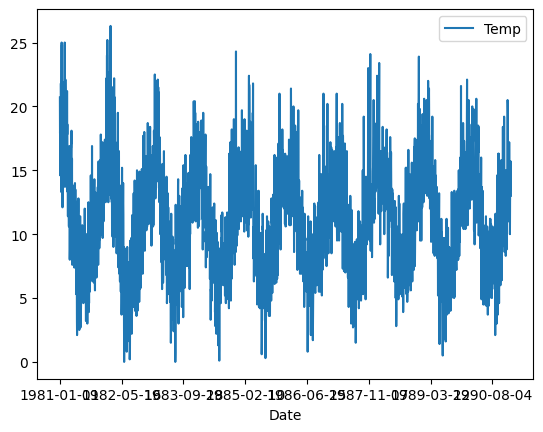

In [5]:
df.plot()

In [6]:
import numpy as np
import matplotlib.pyplot as plt

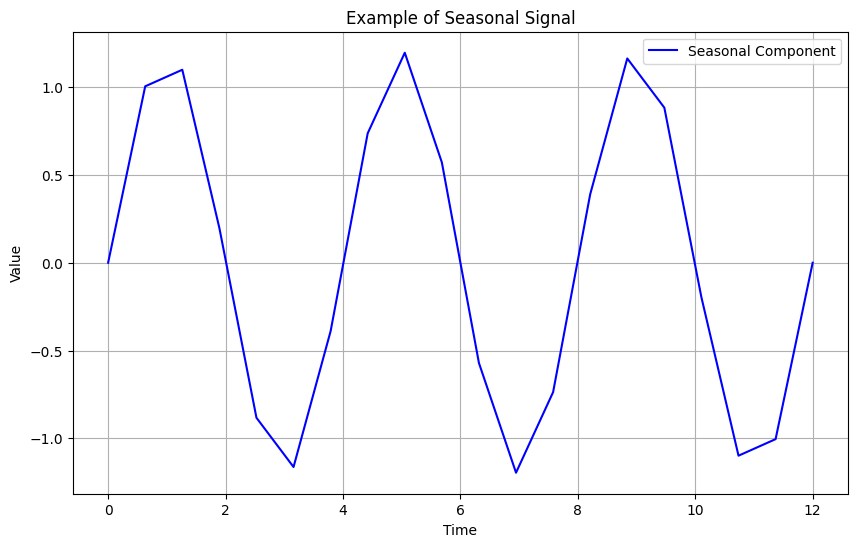

In [8]:
x_axis = np.linspace(0,12,num=20)
seasonality = 1.2 * np.sin(2*np.pi*x_axis/4)

plt.figure(figsize=(10,6))
plt.plot(x_axis,seasonality,label="Seasonal Component",color="b")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Example of Seasonal Signal")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
from statsmodels.tsa.stattools import kpss
def kpss_test(series):
    statistic,p_value, n_lags, critical_values = kpss(series)
    print(f"KPSS Statistic : {statistic:.4f}")
    print(f"P-VALUE : {p_value:.4f}")
    print(f"Number of Lags : {n_lags}")
    print("Critical Values")
    for key,value in critical_values.items():
        print(f"{key}:{value:.4f}")
    print(f"Result: The series is {"not " if p_value<0.05 else ""}stationary")

kpss_test(df["Temp"])

KPSS Statistic : 0.0557
P-VALUE : 0.1000
Number of Lags : 36
Critical Values
10%:0.3470
5%:0.4630
2.5%:0.5740
1%:0.7390
Result: The series is stationary


C:\Users\admin\AppData\Local\Temp\ipykernel_2328\1401284950.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic,p_value, n_lags, critical_values = kpss(series)


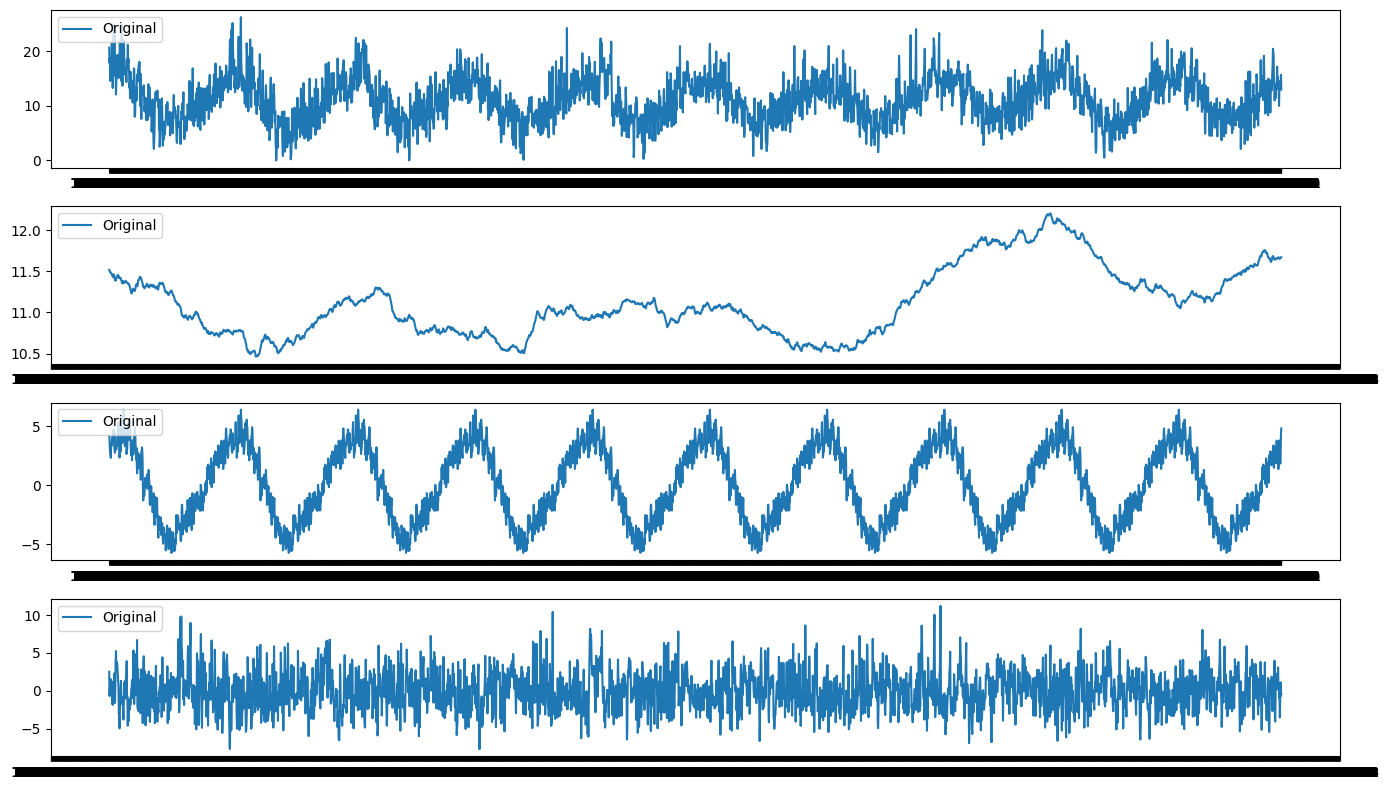

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df["Temp"], model="additive", period=365)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(14,8))
plt.subplot(411)
plt.plot(df["Temp"],label="Original")
plt.legend(loc="upper left")
plt.subplot(412)
plt.plot(trend,label="Original")
plt.legend(loc="upper left")
plt.subplot(413)
plt.plot(seasonal,label="Original")
plt.legend(loc="upper left")
plt.subplot(414)
plt.plot(residual,label="Original")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()